<a href="https://colab.research.google.com/github/eflydata/bellabeatcasestudy/blob/main/bellabeat_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
list.files('/content/')

[1] "daily_activity.csv"     "daily_calories.csv"     "daily_intensities.csv" 
 [4] "dailySteps_merged.csv"  "heartrate_seconds.csv"  "hourly_calories.csv"   
 [7] "hourly_intensities.csv" "hourly_steps.csv"       "minute_calories.csv"   
[10] "minute_intensities.csv" "minute_mets.csv"        "minute_sleep.csv"      
[13] "minute_steps.csv"       "sample_data"            "sleep_day.csv"         
[16] "weight_log.csv"

In [30]:
read.csv ('/content/daily_activity.csv')

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,4/12/2016,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,4/13/2016,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,4/14/2016,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,4/15/2016,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,4/16/2016,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,4/17/2016,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


In [34]:
install.packages(c(
  "tidyverse",
  "lubridate",
  "janitor",
  "skimr",
  "corrplot",
  "GGally",
  "ggplot2",
  "scales"
))

library(tidyverse)
library(lubridate)
library(janitor)
library(skimr)
library(GGally)
library(ggplot2)
library(scales)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [36]:
daily_activity <- read.csv('/content/daily_activity.csv')
glimpse(daily_activity)
summary(daily_activity)
skim(daily_activity)
head(daily_activity)

Rows: 940
Columns: 15
$ Id                       <dbl> 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityDate             <chr> "4/12/2016", "4/13/2016", "4/14/2016", "4/15/…
$ TotalSteps               <int> 13162, 10735, 10460, 9762, 12669, 9705, 13019…
$ TotalDistance            <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ TrackerDistance          <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ LoggedActivitiesDistance <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveDistance       <dbl> 1.88, 1.57, 2.44, 2.14, 2.71, 3.19, 3.25, 3.5…
$ ModeratelyActiveDistance <dbl> 0.55, 0.69, 0.40, 1.26, 0.41, 0.78, 0.64, 1.3…
$ LightActiveDistance      <dbl> 6.06, 4.71, 3.91, 2.83, 5.04, 2.51, 4.71, 5.0…
$ SedentaryActiveDistance  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveMinutes        <int> 25, 21, 30, 29, 36, 38, 42, 50, 28, 19, 66, 4…
$ FairlyActiveMinutes      <int> 13, 19, 11, 34, 10, 20, 16, 31, 12, 8, 27, 21…
$ LightlyActiveMin

       Id               ActivityDate   TotalSteps    TotalDistance   
 Min.   :1.504e+09   Length   :940   Min.   :    0   Min.   : 0.000  
 1st Qu.:2.320e+09   N.unique : 31   1st Qu.: 3790   1st Qu.: 2.620  
 Median :4.445e+09   N.blank  :  0   Median : 7406   Median : 5.245  
 Mean   :4.855e+09   Min.nchar:  8   Mean   : 7638   Mean   : 5.490  
 3rd Qu.:6.962e+09   Max.nchar:  9   3rd Qu.:10727   3rd Qu.: 7.713  
 Max.   :8.878e+09                   Max.   :36019   Max.   :28.030  
 TrackerDistance  LoggedActivitiesDistance VeryActiveDistance
 Min.   : 0.000   Min.   :0.0000           Min.   : 0.000    
 1st Qu.: 2.620   1st Qu.:0.0000           1st Qu.: 0.000    
 Median : 5.245   Median :0.0000           Median : 0.210    
 Mean   : 5.475   Mean   :0.1082           Mean   : 1.503    
 3rd Qu.: 7.710   3rd Qu.:0.0000           3rd Qu.: 2.052    
 Max.   :28.030   Max.   :4.9421           Max.   :21.920    
 ModeratelyActiveDistance LightActiveDistance SedentaryActiveDistance
 Min. 

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityDate,0,1,8,9,0,31,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.855407e+09,2.424805e+09,1503960366,2.320127e+09,4.445115e+09,6.962181e+09,8.877689e+09,▇▅▃▅▅
3,numeric,TotalSteps,0,1,NA,NA,NA,NA,NA,7.637911e+03,5.087151e+03,0,3.789750e+03,7.405500e+03,1.072700e+04,3.601900e+04,▇▇▁▁▁
4,numeric,TotalDistance,0,1,NA,NA,NA,NA,NA,5.489702e+00,3.924606e+00,0,2.620000e+00,5.245000e+00,7.712500e+00,2.803000e+01,▇▆▁▁▁
5,numeric,TrackerDistance,0,1,NA,NA,NA,NA,NA,5.475351e+00,3.907276e+00,0,2.620000e+00,5.245000e+00,7.710000e+00,2.803000e+01,▇▆▁▁▁
6,numeric,LoggedActivitiesDistance,0,1,NA,NA,NA,NA,NA,1.081709e-01,6.198965e-01,0,0.000000e+00,0.000000e+00,0.000000e+00,4.942142e+00,▇▁▁▁▁
7,numeric,VeryActiveDistance,0,1,NA,NA,NA,NA,NA,1.502681e+00,2.658941e+00,0,0.000000e+00,2.100000e-01,2.052500e+00,2.192000e+01,▇▁▁▁▁
8,numeric,ModeratelyActiveDistance,0,1,NA,NA,NA,NA,NA,5.675426e-01,8.835803e-01,0,0.000000e+00,2.400000e-01,8.000000e-01,6.480000e+00,▇▁▁▁▁
9,numeric,LightActiveDistance,0,1,NA,NA,NA,NA,NA,3.340819e+00,2.040655e+00,0,1.945000e+00,3.365000e+00,4.782500e+00,1.071000e+01,▆▇▆▁▁


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,4/12/2016,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,4/13/2016,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,4/14/2016,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,4/15/2016,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,4/16/2016,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,4/17/2016,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


In [41]:
dailySteps_merged <- read.csv('/content/dailySteps_merged.csv')

glimpse(dailySteps_merged)
summary(dailySteps_merged)
skim(dailySteps_merged)
head(dailySteps_merged)

Rows: 940
Columns: 3
$ Id          <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 1503960366…
$ ActivityDay <chr> "4/12/2016", "4/13/2016", "4/14/2016", "4/15/2016", "4/16/…
$ StepTotal   <int> 13162, 10735, 10460, 9762, 12669, 9705, 13019, 15506, 1054…


       Id               ActivityDay    StepTotal    
 Min.   :1.504e+09   Length   :940   Min.   :    0  
 1st Qu.:2.320e+09   N.unique : 31   1st Qu.: 3790  
 Median :4.445e+09   N.blank  :  0   Median : 7406  
 Mean   :4.855e+09   Min.nchar:  8   Mean   : 7638  
 3rd Qu.:6.962e+09   Max.nchar:  9   3rd Qu.:10727  
 Max.   :8.878e+09                   Max.   :36019  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityDay,0,1,8,9,0,31,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.855407e+09,2.424805e+09,1503960366,2.320127e+09,4445114986.0,6962181067,8877689391,▇▅▃▅▅
3,numeric,StepTotal,0,1,NA,NA,NA,NA,NA,7.637911e+03,5.087151e+03,0,3.789750e+03,7405.5,10727,36019,▇▇▁▁▁


,Id,ActivityDay,StepTotal
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016,13162
2,1503960366,4/13/2016,10735
3,1503960366,4/14/2016,10460
4,1503960366,4/15/2016,9762
5,1503960366,4/16/2016,12669
6,1503960366,4/17/2016,9705


In [42]:
daily_calories <- read.csv('/content/daily_calories.csv')
glimpse(daily_calories)
summary(daily_calories)
skim(daily_calories)
head(daily_calories)

Rows: 940
Columns: 3
$ Id          <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 1503960366…
$ ActivityDay <chr> "4/12/2016", "4/13/2016", "4/14/2016", "4/15/2016", "4/16/…
$ Calories    <int> 1985, 1797, 1776, 1745, 1863, 1728, 1921, 2035, 1786, 1775…


       Id               ActivityDay     Calories   
 Min.   :1.504e+09   Length   :940   Min.   :   0  
 1st Qu.:2.320e+09   N.unique : 31   1st Qu.:1828  
 Median :4.445e+09   N.blank  :  0   Median :2134  
 Mean   :4.855e+09   Min.nchar:  8   Mean   :2304  
 3rd Qu.:6.962e+09   Max.nchar:  9   3rd Qu.:2793  
 Max.   :8.878e+09                   Max.   :4900  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityDay,0,1,8,9,0,31,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.855407e+09,2.424805e+09,1503960366,2320127002.0,4445114986,6.962181e+09,8877689391,▇▅▃▅▅
3,numeric,Calories,0,1,NA,NA,NA,NA,NA,2.303610e+03,7.181669e+02,0,1828.5,2134,2.793250e+03,4900,▁▆▇▃▁


,Id,ActivityDay,Calories
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016,1985
2,1503960366,4/13/2016,1797
3,1503960366,4/14/2016,1776
4,1503960366,4/15/2016,1745
5,1503960366,4/16/2016,1863
6,1503960366,4/17/2016,1728


In [43]:
daily_intensities <- read.csv('/content/daily_intensities.csv')
glimpse(daily_intensities)
summary(daily_intensities)
skim(daily_intensities)
head(daily_intensities)

Rows: 940
Columns: 10
$ Id                       <dbl> 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityDay              <chr> "4/12/2016", "4/13/2016", "4/14/2016", "4/15/…
$ SedentaryMinutes         <int> 728, 776, 1218, 726, 773, 539, 1149, 775, 818…
$ LightlyActiveMinutes     <int> 328, 217, 181, 209, 221, 164, 233, 264, 205, …
$ FairlyActiveMinutes      <int> 13, 19, 11, 34, 10, 20, 16, 31, 12, 8, 27, 21…
$ VeryActiveMinutes        <int> 25, 21, 30, 29, 36, 38, 42, 50, 28, 19, 66, 4…
$ SedentaryActiveDistance  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ LightActiveDistance      <dbl> 6.06, 4.71, 3.91, 2.83, 5.04, 2.51, 4.71, 5.0…
$ ModeratelyActiveDistance <dbl> 0.55, 0.69, 0.40, 1.26, 0.41, 0.78, 0.64, 1.3…
$ VeryActiveDistance       <dbl> 1.88, 1.57, 2.44, 2.14, 2.71, 3.19, 3.25, 3.5…


       Id               ActivityDay  SedentaryMinutes LightlyActiveMinutes
 Min.   :1.504e+09   Length   :940   Min.   :   0.0   Min.   :  0.0       
 1st Qu.:2.320e+09   N.unique : 31   1st Qu.: 729.8   1st Qu.:127.0       
 Median :4.445e+09   N.blank  :  0   Median :1057.5   Median :199.0       
 Mean   :4.855e+09   Min.nchar:  8   Mean   : 991.2   Mean   :192.8       
 3rd Qu.:6.962e+09   Max.nchar:  9   3rd Qu.:1229.5   3rd Qu.:264.0       
 Max.   :8.878e+09                   Max.   :1440.0   Max.   :518.0       
 FairlyActiveMinutes VeryActiveMinutes SedentaryActiveDistance
 Min.   :  0.00      Min.   :  0.00    Min.   :0.000000       
 1st Qu.:  0.00      1st Qu.:  0.00    1st Qu.:0.000000       
 Median :  6.00      Median :  4.00    Median :0.000000       
 Mean   : 13.56      Mean   : 21.16    Mean   :0.001606       
 3rd Qu.: 19.00      3rd Qu.: 32.00    3rd Qu.:0.000000       
 Max.   :143.00      Max.   :210.00    Max.   :0.110000       
 LightActiveDistance ModeratelyAct

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityDay,0,1,8,9,0,31,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.855407e+09,2.424805e+09,1503960366,2.320127e+09,4.445115e+09,6.962181e+09,8.877689e+09,▇▅▃▅▅
3,numeric,SedentaryMinutes,0,1,NA,NA,NA,NA,NA,9.912106e+02,3.012674e+02,0,7.297500e+02,1.057500e+03,1.229500e+03,1.440000e+03,▁▁▇▅▇
4,numeric,LightlyActiveMinutes,0,1,NA,NA,NA,NA,NA,1.928128e+02,1.091747e+02,0,1.270000e+02,1.990000e+02,2.640000e+02,5.180000e+02,▅▇▇▃▁
5,numeric,FairlyActiveMinutes,0,1,NA,NA,NA,NA,NA,1.356489e+01,1.998740e+01,0,0.000000e+00,6.000000e+00,1.900000e+01,1.430000e+02,▇▁▁▁▁
6,numeric,VeryActiveMinutes,0,1,NA,NA,NA,NA,NA,2.116489e+01,3.284480e+01,0,0.000000e+00,4.000000e+00,3.200000e+01,2.100000e+02,▇▁▁▁▁
7,numeric,SedentaryActiveDistance,0,1,NA,NA,NA,NA,NA,1.606383e-03,7.346176e-03,0,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e-01,▇▁▁▁▁
8,numeric,LightActiveDistance,0,1,NA,NA,NA,NA,NA,3.340819e+00,2.040655e+00,0,1.945000e+00,3.365000e+00,4.782500e+00,1.071000e+01,▆▇▆▁▁
9,numeric,ModeratelyActiveDistance,0,1,NA,NA,NA,NA,NA,5.675426e-01,8.835803e-01,0,0.000000e+00,2.400000e-01,8.000000e-01,6.480000e+00,▇▁▁▁▁


,Id,ActivityDay,SedentaryMinutes,LightlyActiveMinutes,FairlyActiveMinutes,VeryActiveMinutes,SedentaryActiveDistance,LightActiveDistance,ModeratelyActiveDistance,VeryActiveDistance
,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,1503960366,4/12/2016,728,328,13,25,0,6.06,0.55,1.88
2,1503960366,4/13/2016,776,217,19,21,0,4.71,0.69,1.57
3,1503960366,4/14/2016,1218,181,11,30,0,3.91,0.40,2.44
4,1503960366,4/15/2016,726,209,34,29,0,2.83,1.26,2.14
5,1503960366,4/16/2016,773,221,10,36,0,5.04,0.41,2.71
6,1503960366,4/17/2016,539,164,20,38,0,2.51,0.78,3.19


In [44]:
heartrate_seconds <- read.csv('/content/heartrate_seconds.csv')
glimpse(heartrate_seconds)
summary(heartrate_seconds)
skim(heartrate_seconds)
head(heartrate_seconds)

Rows: 2,483,658
Columns: 3
$ Id    <dbl> 2022484408, 2022484408, 2022484408, 2022484408, 2022484408, 2022…
$ Time  <chr> "4/12/2016 7:21:00 AM", "4/12/2016 7:21:05 AM", "4/12/2016 7:21:…
$ Value <int> 97, 102, 105, 103, 101, 95, 91, 93, 94, 93, 92, 89, 83, 61, 60, …


       Id                   Time             Value       
 Min.   :2.022e+09   Length   :2483658   Min.   : 36.00  
 1st Qu.:4.388e+09   N.unique : 961274   1st Qu.: 63.00  
 Median :5.554e+09   N.blank  :      0   Median : 73.00  
 Mean   :5.514e+09   Min.nchar:     19   Mean   : 77.33  
 3rd Qu.:6.962e+09   Max.nchar:     21   3rd Qu.: 88.00  
 Max.   :8.878e+09                       Max.   :203.00  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,Time,0,1,19,21,0,961274,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,5.513765e+09,1.950224e+09,2022484408,4388161847,5553957443,6962181067,8877689391,▃▇▇▅▃
3,numeric,Value,0,1,NA,NA,NA,NA,NA,7.732842e+01,1.940450e+01,36,63,73,88,203,▇▇▁▁▁


,Id,Time,Value
,<dbl>,<chr>,<int>
1,2022484408,4/12/2016 7:21:00 AM,97
2,2022484408,4/12/2016 7:21:05 AM,102
3,2022484408,4/12/2016 7:21:10 AM,105
4,2022484408,4/12/2016 7:21:20 AM,103
5,2022484408,4/12/2016 7:21:25 AM,101
6,2022484408,4/12/2016 7:22:05 AM,95


In [45]:
hourly_calories <- read.csv('/content/hourly_calories.csv')
glimpse(hourly_calories)
summary(hourly_calories)
skim(hourly_calories)
head(hourly_calories)

Rows: 22,099
Columns: 3
$ Id           <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityHour <chr> "4/12/2016 12:00:00 AM", "4/12/2016 1:00:00 AM", "4/12/20…
$ Calories     <int> 81, 61, 59, 47, 48, 48, 48, 47, 68, 141, 99, 76, 73, 66, …


       Id               ActivityHour      Calories     
 Min.   :1.504e+09   Length   :22099   Min.   : 42.00  
 1st Qu.:2.320e+09   N.unique :  736   1st Qu.: 63.00  
 Median :4.445e+09   N.blank  :    0   Median : 83.00  
 Mean   :4.848e+09   Min.nchar:   19   Mean   : 97.39  
 3rd Qu.:6.962e+09   Max.nchar:   21   3rd Qu.:108.00  
 Max.   :8.878e+09                     Max.   :948.00  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityHour,0,1,19,21,0,736,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.848235e+09,2.422500e+09,1503960366,2320127002,4445114986,6962181067,8877689391,▇▅▃▅▅
3,numeric,Calories,0,1,NA,NA,NA,NA,NA,9.738676e+01,6.070262e+01,42,63,83,108,948,▇▁▁▁▁


,Id,ActivityHour,Calories
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,81
2,1503960366,4/12/2016 1:00:00 AM,61
3,1503960366,4/12/2016 2:00:00 AM,59
4,1503960366,4/12/2016 3:00:00 AM,47
5,1503960366,4/12/2016 4:00:00 AM,48
6,1503960366,4/12/2016 5:00:00 AM,48


In [46]:
hourly_intensities <- read.csv('/content/hourly_intensities.csv')
glimpse(hourly_intensities)
summary(hourly_intensities)
skim(hourly_intensities)
head(hourly_intensities)

Rows: 22,099
Columns: 4
$ Id               <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 15039…
$ ActivityHour     <chr> "4/12/2016 12:00:00 AM", "4/12/2016 1:00:00 AM", "4/1…
$ TotalIntensity   <int> 20, 8, 7, 0, 0, 0, 0, 0, 13, 30, 29, 12, 11, 6, 36, 5…
$ AverageIntensity <dbl> 0.333333, 0.133333, 0.116667, 0.000000, 0.000000, 0.0…


       Id               ActivityHour   TotalIntensity   AverageIntensity
 Min.   :1.504e+09   Length   :22099   Min.   :  0.00   Min.   :0.0000  
 1st Qu.:2.320e+09   N.unique :  736   1st Qu.:  0.00   1st Qu.:0.0000  
 Median :4.445e+09   N.blank  :    0   Median :  3.00   Median :0.0500  
 Mean   :4.848e+09   Min.nchar:   19   Mean   : 12.04   Mean   :0.2006  
 3rd Qu.:6.962e+09   Max.nchar:   21   3rd Qu.: 16.00   3rd Qu.:0.2667  
 Max.   :8.878e+09                     Max.   :180.00   Max.   :3.0000  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityHour,0,1,19,21,0,736,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.848235e+09,2.422500e+09,1503960366,2320127002,4.445115e+09,6.962181e+09,8877689391,▇▅▃▅▅
3,numeric,TotalIntensity,0,1,NA,NA,NA,NA,NA,1.203534e+01,2.113311e+01,0,0,3.000000e+00,1.600000e+01,180,▇▁▁▁▁
4,numeric,AverageIntensity,0,1,NA,NA,NA,NA,NA,2.005890e-01,3.522185e-01,0,0,5.000000e-02,2.666670e-01,3,▇▁▁▁▁


,Id,ActivityHour,TotalIntensity,AverageIntensity
,<dbl>,<chr>,<int>,<dbl>
1,1503960366,4/12/2016 12:00:00 AM,20,0.333333
2,1503960366,4/12/2016 1:00:00 AM,8,0.133333
3,1503960366,4/12/2016 2:00:00 AM,7,0.116667
4,1503960366,4/12/2016 3:00:00 AM,0,0.000000
5,1503960366,4/12/2016 4:00:00 AM,0,0.000000
6,1503960366,4/12/2016 5:00:00 AM,0,0.000000


In [47]:
hourly_steps <- read.csv('/content/hourly_steps.csv')
glimpse(hourly_steps)
summary(hourly_steps)
skim(hourly_steps)
head(hourly_steps)

Rows: 22,099
Columns: 3
$ Id           <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityHour <chr> "4/12/2016 12:00:00 AM", "4/12/2016 1:00:00 AM", "4/12/20…
$ StepTotal    <int> 373, 160, 151, 0, 0, 0, 0, 0, 250, 1864, 676, 360, 253, 2…


       Id               ActivityHour     StepTotal      
 Min.   :1.504e+09   Length   :22099   Min.   :    0.0  
 1st Qu.:2.320e+09   N.unique :  736   1st Qu.:    0.0  
 Median :4.445e+09   N.blank  :    0   Median :   40.0  
 Mean   :4.848e+09   Min.nchar:   19   Mean   :  320.2  
 3rd Qu.:6.962e+09   Max.nchar:   21   3rd Qu.:  357.0  
 Max.   :8.878e+09                     Max.   :10554.0  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityHour,0,1,19,21,0,736,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.848235e+09,2.422500e+09,1503960366,2320127002,4445114986,6962181067,8877689391,▇▅▃▅▅
3,numeric,StepTotal,0,1,NA,NA,NA,NA,NA,3.201663e+02,6.903842e+02,0,0,40,357,10554,▇▁▁▁▁


,Id,ActivityHour,StepTotal
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,373
2,1503960366,4/12/2016 1:00:00 AM,160
3,1503960366,4/12/2016 2:00:00 AM,151
4,1503960366,4/12/2016 3:00:00 AM,0
5,1503960366,4/12/2016 4:00:00 AM,0
6,1503960366,4/12/2016 5:00:00 AM,0


In [48]:
minute_calories <- read.csv('/content/minute_calories.csv')
glimpse(minute_calories)
summary(minute_calories)
skim(minute_calories)
head(minute_calories)

Rows: 1,325,580
Columns: 3
$ Id             <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 1503960…
$ ActivityMinute <chr> "4/12/2016 12:00:00 AM", "4/12/2016 12:01:00 AM", "4/12…
$ Calories       <dbl> 0.7865, 0.7865, 0.7865, 0.7865, 0.7865, 0.9438, 0.9438,…


       Id              ActivityMinute       Calories      
 Min.   :1.504e+09   Length   :1325580   Min.   : 0.0000  
 1st Qu.:2.320e+09   N.unique :  44160   1st Qu.: 0.9357  
 Median :4.445e+09   N.blank  :      0   Median : 1.2176  
 Mean   :4.848e+09   Min.nchar:     19   Mean   : 1.6231  
 3rd Qu.:6.962e+09   Max.nchar:     21   3rd Qu.: 1.4327  
 Max.   :8.878e+09                       Max.   :19.7499  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityMinute,0,1,19,21,0,44160,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.847898e+09,2.422313e+09,1503960366,2.320127e+09,4.445115e+09,6.962181e+09,8.877689e+09,▇▅▃▅▅
3,numeric,Calories,0,1,NA,NA,NA,NA,NA,1.623130e+00,1.410447e+00,0,9.357000e-01,1.217600e+00,1.432700e+00,1.974995e+01,▇▁▁▁▁


,Id,ActivityMinute,Calories
,<dbl>,<chr>,<dbl>
1,1503960366,4/12/2016 12:00:00 AM,0.7865
2,1503960366,4/12/2016 12:01:00 AM,0.7865
3,1503960366,4/12/2016 12:02:00 AM,0.7865
4,1503960366,4/12/2016 12:03:00 AM,0.7865
5,1503960366,4/12/2016 12:04:00 AM,0.7865
6,1503960366,4/12/2016 12:05:00 AM,0.9438


In [49]:
minute_intensities <- read.csv('/content/minute_intensities.csv')
glimpse(minute_intensities)
summary(minute_intensities)
skim(minute_intensities)
head(minute_intensities)

Rows: 1,325,580
Columns: 3
$ Id             <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 1503960…
$ ActivityMinute <chr> "4/12/2016 12:00:00 AM", "4/12/2016 12:01:00 AM", "4/12…
$ Intensity      <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…


       Id              ActivityMinute      Intensity     
 Min.   :1.504e+09   Length   :1325580   Min.   :0.0000  
 1st Qu.:2.320e+09   N.unique :  44160   1st Qu.:0.0000  
 Median :4.445e+09   N.blank  :      0   Median :0.0000  
 Mean   :4.848e+09   Min.nchar:     19   Mean   :0.2006  
 3rd Qu.:6.962e+09   Max.nchar:     21   3rd Qu.:0.0000  
 Max.   :8.878e+09                       Max.   :3.0000  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityMinute,0,1,19,21,0,44160,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.847898e+09,2.422313e+09,1503960366,2320127002,4445114986,6962181067,8877689391,▇▅▃▅▅
3,numeric,Intensity,0,1,NA,NA,NA,NA,NA,2.005937e-01,5.190227e-01,0,0,0,0,3,▇▁▁▁▁


,Id,ActivityMinute,Intensity
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,0
2,1503960366,4/12/2016 12:01:00 AM,0
3,1503960366,4/12/2016 12:02:00 AM,0
4,1503960366,4/12/2016 12:03:00 AM,0
5,1503960366,4/12/2016 12:04:00 AM,0
6,1503960366,4/12/2016 12:05:00 AM,0


In [50]:
minute_mets <- read.csv('/content/minute_mets.csv')
glimpse(minute_mets)
summary(minute_mets)
skim(minute_mets)
head(minute_mets)

Rows: 1,325,580
Columns: 3
$ Id             <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 1503960…
$ ActivityMinute <chr> "4/12/2016 12:00:00 AM", "4/12/2016 12:01:00 AM", "4/12…
$ METs           <int> 10, 10, 10, 10, 10, 12, 12, 12, 12, 12, 12, 12, 10, 10,…


       Id              ActivityMinute         METs       
 Min.   :1.504e+09   Length   :1325580   Min.   :  0.00  
 1st Qu.:2.320e+09   N.unique :  44160   1st Qu.: 10.00  
 Median :4.445e+09   N.blank  :      0   Median : 10.00  
 Mean   :4.848e+09   Min.nchar:     19   Mean   : 14.69  
 3rd Qu.:6.962e+09   Max.nchar:     21   3rd Qu.: 11.00  
 Max.   :8.878e+09                       Max.   :157.00  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityMinute,0,1,19,21,0,44160,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.847898e+09,2.422313e+09,1503960366,2320127002,4445114986,6962181067,8877689391,▇▅▃▅▅
3,numeric,METs,0,1,NA,NA,NA,NA,NA,1.469001e+01,1.205541e+01,0,10,10,11,157,▇▁▁▁▁


,Id,ActivityMinute,METs
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,10
2,1503960366,4/12/2016 12:01:00 AM,10
3,1503960366,4/12/2016 12:02:00 AM,10
4,1503960366,4/12/2016 12:03:00 AM,10
5,1503960366,4/12/2016 12:04:00 AM,10
6,1503960366,4/12/2016 12:05:00 AM,12


In [51]:
minute_sleep <- read.csv('/content/minute_sleep.csv')
glimpse(minute_sleep)
summary(minute_sleep)
skim(minute_sleep)
head(minute_sleep)

Rows: 188,521
Columns: 4
$ Id    <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 1503960366, 1503…
$ date  <chr> "4/12/2016 2:47:30 AM", "4/12/2016 2:48:30 AM", "4/12/2016 2:49:…
$ value <int> 3, 2, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1…
$ logId <dbl> 11380564589, 11380564589, 11380564589, 11380564589, 11380564589,…


       Id                   date            value           logId          
 Min.   :1.504e+09   Length   :188521   Min.   :1.000   Min.   :1.137e+10  
 1st Qu.:3.977e+09   N.unique : 49773   1st Qu.:1.000   1st Qu.:1.144e+10  
 Median :4.703e+09   N.blank  :     0   Median :1.000   Median :1.150e+10  
 Mean   :4.997e+09   Min.nchar:    19   Mean   :1.096   Mean   :1.150e+10  
 3rd Qu.:6.962e+09   Max.nchar:    21   3rd Qu.:1.000   3rd Qu.:1.155e+10  
 Max.   :8.792e+09                      Max.   :3.000   Max.   :1.162e+10  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,date,0,1,19,21,0,49773,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.996595e+09,2.066950e+09,1503960366,3977333714,4702921684,6962181067,8792009665,▆▆▇▆▃
3,numeric,value,0,1,NA,NA,NA,NA,NA,1.095793e+00,3.286732e-01,1,1,1,1,3,▇▁▁▁▁
4,numeric,logId,0,1,NA,NA,NA,NA,NA,1.149611e+10,6.822863e+07,11372227280,11439308639,11501142214,11552534115,11616251768,▆▇▇▇▇


,Id,date,value,logId
,<dbl>,<chr>,<int>,<dbl>
1,1503960366,4/12/2016 2:47:30 AM,3,11380564589
2,1503960366,4/12/2016 2:48:30 AM,2,11380564589
3,1503960366,4/12/2016 2:49:30 AM,1,11380564589
4,1503960366,4/12/2016 2:50:30 AM,1,11380564589
5,1503960366,4/12/2016 2:51:30 AM,1,11380564589
6,1503960366,4/12/2016 2:52:30 AM,1,11380564589


In [52]:
minute_steps <- read.csv('/content/minute_steps.csv')
glimpse(minute_steps)
summary(minute_steps)
skim(minute_steps)
head(minute_steps)

Rows: 1,325,580
Columns: 3
$ Id             <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 1503960…
$ ActivityMinute <chr> "4/12/2016 12:00:00 AM", "4/12/2016 12:01:00 AM", "4/12…
$ Steps          <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…


       Id              ActivityMinute        Steps        
 Min.   :1.504e+09   Length   :1325580   Min.   :  0.000  
 1st Qu.:2.320e+09   N.unique :  44160   1st Qu.:  0.000  
 Median :4.445e+09   N.blank  :      0   Median :  0.000  
 Mean   :4.848e+09   Min.nchar:     19   Mean   :  5.336  
 3rd Qu.:6.962e+09   Max.nchar:     21   3rd Qu.:  0.000  
 Max.   :8.878e+09                       Max.   :220.000  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,ActivityMinute,0,1,19,21,0,44160,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,4.847898e+09,2.422313e+09,1503960366,2320127002,4445114986,6962181067,8877689391,▇▅▃▅▅
3,numeric,Steps,0,1,NA,NA,NA,NA,NA,5.336192e+00,1.812830e+01,0,0,0,0,220,▇▁▁▁▁


,Id,ActivityMinute,Steps
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,0
2,1503960366,4/12/2016 12:01:00 AM,0
3,1503960366,4/12/2016 12:02:00 AM,0
4,1503960366,4/12/2016 12:03:00 AM,0
5,1503960366,4/12/2016 12:04:00 AM,0
6,1503960366,4/12/2016 12:05:00 AM,0


In [53]:
sleep_day <- read.csv('/content/sleep_day.csv')
glimpse(sleep_day)
summary(sleep_day)
skim(sleep_day)
head(sleep_day)

Rows: 413
Columns: 5
$ Id                 <dbl> 1503960366, 1503960366, 1503960366, 1503960366, 150…
$ SleepDay           <chr> "4/12/2016 12:00:00 AM", "4/13/2016 12:00:00 AM", "…
$ TotalSleepRecords  <int> 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ TotalMinutesAsleep <int> 327, 384, 412, 340, 700, 304, 360, 325, 361, 430, 2…
$ TotalTimeInBed     <int> 346, 407, 442, 367, 712, 320, 377, 364, 384, 449, 3…


       Id                 SleepDay   TotalSleepRecords TotalMinutesAsleep
 Min.   :1.504e+09   Length   :413   Min.   :1.000     Min.   : 58.0     
 1st Qu.:3.977e+09   N.unique : 31   1st Qu.:1.000     1st Qu.:361.0     
 Median :4.703e+09   N.blank  :  0   Median :1.000     Median :433.0     
 Mean   :5.001e+09   Min.nchar: 20   Mean   :1.119     Mean   :419.5     
 3rd Qu.:6.962e+09   Max.nchar: 21   3rd Qu.:1.000     3rd Qu.:490.0     
 Max.   :8.792e+09                   Max.   :3.000     Max.   :796.0     
 TotalTimeInBed 
 Min.   : 61.0  
 1st Qu.:403.0  
 Median :463.0  
 Mean   :458.6  
 3rd Qu.:526.0  
 Max.   :961.0  

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,SleepDay,0,1,20,21,0,31,0,NA,NA,NA,NA,NA,NA,NA,NA
2,numeric,Id,0,1,NA,NA,NA,NA,NA,5.000979e+09,2.060360e+09,1503960366,3977333714,4702921684,6962181067,8792009665,▆▆▇▅▃
3,numeric,TotalSleepRecords,0,1,NA,NA,NA,NA,NA,1.118644e+00,3.455207e-01,1,1,1,1,3,▇▁▁▁▁
4,numeric,TotalMinutesAsleep,0,1,NA,NA,NA,NA,NA,4.194673e+02,1.183447e+02,58,361,433,490,796,▁▂▇▃▁
5,numeric,TotalTimeInBed,0,1,NA,NA,NA,NA,NA,4.586392e+02,1.271016e+02,61,403,463,526,961,▁▃▇▁▁


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
,<dbl>,<chr>,<int>,<int>,<int>
1,1503960366,4/12/2016 12:00:00 AM,1,327,346
2,1503960366,4/13/2016 12:00:00 AM,2,384,407
3,1503960366,4/15/2016 12:00:00 AM,1,412,442
4,1503960366,4/16/2016 12:00:00 AM,2,340,367
5,1503960366,4/17/2016 12:00:00 AM,1,700,712
6,1503960366,4/19/2016 12:00:00 AM,1,304,320


In [54]:
weight_log <- read.csv('/content/weight_log.csv')
glimpse(weight_log)
summary(weight_log)
skim(weight_log)
head(weight_log)

Rows: 67
Columns: 8
$ Id             <dbl> 1503960366, 1503960366, 1927972279, 2873212765, 2873212…
$ Date           <chr> "5/2/2016 11:59:59 PM", "5/3/2016 11:59:59 PM", "4/13/2…
$ WeightKg       <dbl> 52.6, 52.6, 133.5, 56.7, 57.3, 72.4, 72.3, 69.7, 70.3, …
$ WeightPounds   <dbl> 115.9631, 115.9631, 294.3171, 125.0021, 126.3249, 159.6…
$ Fat            <int> 22, NA, NA, NA, NA, 25, NA, NA, NA, NA, NA, NA, NA, NA,…
$ BMI            <dbl> 22.65, 22.65, 47.54, 21.45, 21.69, 27.45, 27.38, 27.25,…
$ IsManualReport <chr> "True", "True", "False", "True", "True", "True", "True"…
$ LogId          <dbl> 1.462234e+12, 1.462320e+12, 1.460510e+12, 1.461283e+12,…


       Id                   Date       WeightKg       WeightPounds  
 Min.   :1.504e+09   Length   :67   Min.   : 52.60   Min.   :116.0  
 1st Qu.:6.962e+09   N.unique :56   1st Qu.: 61.40   1st Qu.:135.4  
 Median :6.962e+09   N.blank  : 0   Median : 62.50   Median :137.8  
 Mean   :7.009e+09   Min.nchar:19   Mean   : 72.04   Mean   :158.8  
 3rd Qu.:8.878e+09   Max.nchar:21   3rd Qu.: 85.05   3rd Qu.:187.5  
 Max.   :8.878e+09                  Max.   :133.50   Max.   :294.3  
                                                                    
      Fat             BMI          IsManualReport     LogId          
 Min.   :22.00   Min.   :21.45   Length   :67     Min.   :1.460e+12  
 1st Qu.:22.75   1st Qu.:23.96   N.unique : 2     1st Qu.:1.461e+12  
 Median :23.50   Median :24.39   N.blank  : 0     Median :1.462e+12  
 Mean   :23.50   Mean   :25.19   Min.nchar: 4     Mean   :1.462e+12  
 3rd Qu.:24.25   3rd Qu.:25.56   Max.nchar: 5     3rd Qu.:1.462e+12  
 Max.   :25.00   Max.   :47.

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,Date,0,1.00000000,19,21,0,56,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,IsManualReport,0,1.00000000,4,5,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
3,numeric,Id,0,1.00000000,NA,NA,NA,NA,NA,7.009282e+09,1.950322e+09,1.503960e+09,6.962181e+09,6.962181e+09,8.877689e+09,8.877689e+09,▁▁▂▇▆
4,numeric,WeightKg,0,1.00000000,NA,NA,NA,NA,NA,7.203582e+01,1.392321e+01,5.260000e+01,6.140000e+01,6.250000e+01,8.505000e+01,1.335000e+02,▇▃▃▁▁
5,numeric,WeightPounds,0,1.00000000,NA,NA,NA,NA,NA,1.588118e+02,3.069542e+01,1.159631e+02,1.353638e+02,1.377889e+02,1.875032e+02,2.943171e+02,▇▃▃▁▁
6,numeric,Fat,65,0.02985075,NA,NA,NA,NA,NA,2.350000e+01,2.121320e+00,2.200000e+01,2.275000e+01,2.350000e+01,2.425000e+01,2.500000e+01,▇▁▁▁▇
7,numeric,BMI,0,1.00000000,NA,NA,NA,NA,NA,2.518522e+01,3.066963e+00,2.145000e+01,2.396000e+01,2.439000e+01,2.556000e+01,4.754000e+01,▇▁▁▁▁
8,numeric,LogId,0,1.00000000,NA,NA,NA,NA,NA,1.461772e+12,7.829948e+08,1.460444e+12,1.461079e+12,1.461802e+12,1.462375e+12,1.463098e+12,▇▇▆▇▇


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
,<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<dbl>
1,1503960366,5/2/2016 11:59:59 PM,52.6,115.9631,22,22.65,True,1.462234e+12
2,1503960366,5/3/2016 11:59:59 PM,52.6,115.9631,NA,22.65,True,1.462320e+12
3,1927972279,4/13/2016 1:08:52 AM,133.5,294.3171,NA,47.54,False,1.460510e+12
4,2873212765,4/21/2016 11:59:59 PM,56.7,125.0021,NA,21.45,True,1.461283e+12
5,2873212765,5/12/2016 11:59:59 PM,57.3,126.3249,NA,21.69,True,1.463098e+12
6,4319703577,4/17/2016 11:59:59 PM,72.4,159.6147,25,27.45,True,1.460938e+12


In [82]:
# Check that date data is consistent across daily tables
daily_activity$ActivityDate <- mdy(daily_activity$ActivityDate)
daily_calories$ActivityDay <- mdy(daily_calories$ActivityDay)
daily_intensities$ActivityDay <- mdy(daily_intensities$ActivityDay)
dailySteps_merged$ActivityDay <- mdy(dailySteps_merged$ActivityDay)



In [83]:
# Check that datetime data is consistent across hourly tables
hourly_calories$ActivityHour <- mdy_hms(hourly_calories$ActivityHour)
hourly_intensities$ActivityHour <- mdy_hms(hourly_intensities$ActivityHour)
hourly_steps$ActivityHour <- mdy_hms(hourly_steps$ActivityHour)
weight_log$Date <- mdy_hms(weight_log$Date)


In [72]:
# Check that datetime data is consistent across minute tables
minute_calories$ActivityMinute <- mdy_hms(minute_calories$ActivityMinute)
minute_intensities$ActivityMinute <- mdy_hms(minute_intensities$ActivityMinute)
minute_sleep$date <- mdy_hms(minute_sleep$date)


In [74]:
# minute_steps is different, and needs to be converted to the same date_time format
minute_steps <- read.csv('/content/minute_steps.csv') %>%
  mutate(ActivityMinute = parse_date_time(ActivityMinute, "m/d/Y I:M:S p"))

In [75]:
# Check heartrate_seconds for compatible datetime format
heartrate_seconds$Time <- mdy_hms(heartrate_seconds$Time)

In [120]:
# Check missing values
colSums(is.na(daily_activity))
colSums(is.na(dailySteps_merged))
colSums(is.na(daily_calories))
colSums(is.na(daily_intensities))
colSums(is.na(heartrate_seconds))
colSums(is.na(hourly_calories))
colSums(is.na(hourly_intensities))
colSums(is.na(hourly_steps))
colSums(is.na(minute_calories))
colSums(is.na(minute_intensities))
colSums(is.na(minute_mets))
colSums(is.na(minute_sleep))
colSums(is.na(minute_steps))
colSums(is.na(sleep_day))
colSums(is.na(weight_log))

Id                     ActivityDate 
                               0                              888 
                      TotalSteps                    TotalDistance 
                               0                                0 
                 TrackerDistance         LoggedActivitiesDistance 
                               0                                0 
              VeryActiveDistance         ModeratelyActiveDistance 
                               0                                0 
             LightActiveDistance          SedentaryActiveDistance 
                               0                                0 
               VeryActiveMinutes              FairlyActiveMinutes 
                               0                                0 
            LightlyActiveMinutes                 SedentaryMinutes 
                               0                                0 
                        Calories wday(ActivityDate, label = TRUE) 
                               0                              888

Id ActivityDay   StepTotal 
          0         876           0

Id ActivityDay    Calories 
          0         874           0

Id              ActivityDay         SedentaryMinutes 
                       0                      878                        0 
    LightlyActiveMinutes      FairlyActiveMinutes        VeryActiveMinutes 
                       0                        0                        0 
 SedentaryActiveDistance      LightActiveDistance ModeratelyActiveDistance 
                       0                        0                        0 
      VeryActiveDistance 
                       0

Id  Time Value 
    0  1769     0

...

Id ActivityMinute           METs 
             0           1979              0

Id  date value logId 
    0  1273     0     0

Id ActivityMinute          Steps 
             0              0              0

Id           SleepDay  TotalSleepRecords TotalMinutesAsleep 
                 0                410                  0                  0 
    TotalTimeInBed 
                 0

Id           Date       WeightKg   WeightPounds            Fat 
             0             67              0              0             65 
           BMI IsManualReport          LogId 
             0              0              0

There are 0 missing values

In [84]:
# Remove duplicates
daily_activity <- distinct(daily_activity)
dailySteps_merged <- distinct(dailySteps_merged)
daily_calories <- distinct(daily_calories)
daily_intensities <- distinct(daily_intensities)
heartrate_seconds <- distinct(heartrate_seconds)
hourly_calories <- distinct(hourly_calories)
hourly_intensities <- distinct(hourly_intensities)
hourly_steps <- distinct(hourly_steps)
minute_calories <- distinct(minute_calories)
minute_intensities <- distinct(minute_intensities)
minute_mets <- distinct(minute_mets)
minute_sleep <- distinct(minute_sleep)
minute_steps <- distinct(minute_steps)
sleep_day <- distinct(sleep_day)
weight_log <- distinct(weight_log)

In [87]:
daily_activity %>%
summarize(
avg_steps = mean(TotalSteps),
avg_calories = mean(Calories),
avg_distance = mean(TotalDistance)
)

avg_steps,avg_calories,avg_distance
<dbl>,<dbl>,<dbl>
8085.176,2332.038,5.811171


In [94]:
sleep_day %>%
summarize(
avg_sleep = mean(TotalMinutesAsleep),
avg_time_in_bed = mean(TotalTimeInBed)
)

avg_sleep,avg_time_in_bed
<dbl>,<dbl>
419.1732,458.4829


In [89]:
sleep_day %>%
mutate(
SleepEfficiency = TotalMinutesAsleep /
TotalTimeInBed
)

Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,SleepEfficiency
<dbl>,<date>,<int>,<int>,<int>,<dbl>
1503960366,NA,1,327,346,0.9450867
1503960366,NA,2,384,407,0.9434889
1503960366,NA,1,412,442,0.9321267
1503960366,NA,2,340,367,0.9264305
1503960366,NA,1,700,712,0.9831461
1503960366,NA,1,304,320,0.9500000
1503960366,NA,1,360,377,0.9549072
1503960366,NA,1,325,364,0.8928571
1503960366,NA,1,361,384,0.9401042


In [99]:
hourly_intensities <- hourly_intensities %>%
  mutate(TimeOfDay = case_when(
    hour(ActivityHour) >= 5 & hour(ActivityHour) < 12 ~ "Morning",
    hour(ActivityHour) >= 12 & hour(ActivityHour) < 17 ~ "Afternoon",
    hour(ActivityHour) >= 17 & hour(ActivityHour) < 21 ~ "Evening",
    TRUE ~ "Night"
  ))

In [101]:
daily_activity <- daily_activity %>%
  mutate(wday(ActivityDate,
label = TRUE)
)

In [118]:
ggplot(daily_calories, aes(x = ActivityDay, y = Calories))

ERROR while rich displaying an object: Error in seq.int(from = unclass(cfrom), to = unclass(cto), by = by): 'from' must be a finite number

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_conten

In [119]:
summary(daily_calories$ActivityDay)
sum(is.na(daily_calories$ActivityDay))

Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
     NA      NA      NA   "NaN"      NA      NA   "874"

[1] 874

In [121]:
daily_calories <- read.csv('/content/daily_calories.csv') %>%
  mutate(ActivityDay = parse_date_time(ActivityDay, "m/d/Y"))

# Verify the conversion
summary(daily_calories$ActivityDay)
sum(is.na(daily_calories$ActivityDay))

                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 00:00:00" "2016-04-26 00:00:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 06:53:37" "2016-05-04 00:00:00" "2016-05-12 00:00:00" 

[1] 0

### Re-parsing Daily Tables' Date Columns

In [122]:
# Reload daily_activity and re-parse ActivityDate
daily_activity <- read.csv('/content/daily_activity.csv') %>%
  mutate(ActivityDate = parse_date_time(ActivityDate, "m/d/Y"))

# Verify the conversion
print("daily_activity$ActivityDate verification:")
summary(daily_activity$ActivityDate)
sum(is.na(daily_activity$ActivityDate))

[1] "daily_activity$ActivityDate verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 00:00:00" "2016-04-26 00:00:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 06:53:37" "2016-05-04 00:00:00" "2016-05-12 00:00:00" 

[1] 0

In [123]:
# Reload daily_intensities and re-parse ActivityDay
daily_intensities <- read.csv('/content/daily_intensities.csv') %>%
  mutate(ActivityDay = parse_date_time(ActivityDay, "m/d/Y"))

# Verify the conversion
print("daily_intensities$ActivityDay verification:")
summary(daily_intensities$ActivityDay)
sum(is.na(daily_intensities$ActivityDay))

[1] "daily_intensities$ActivityDay verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 00:00:00" "2016-04-26 00:00:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 06:53:37" "2016-05-04 00:00:00" "2016-05-12 00:00:00" 

[1] 0

In [124]:
# Reload dailySteps_merged and re-parse ActivityDay
dailySteps_merged <- read.csv('/content/dailySteps_merged.csv') %>%
  mutate(ActivityDay = parse_date_time(ActivityDay, "m/d/Y"))

# Verify the conversion
print("dailySteps_merged$ActivityDay verification:")
summary(dailySteps_merged$ActivityDay)
sum(is.na(dailySteps_merged$ActivityDay))

[1] "dailySteps_merged$ActivityDay verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 00:00:00" "2016-04-26 00:00:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 06:53:37" "2016-05-04 00:00:00" "2016-05-12 00:00:00" 

[1] 0

### Re-parsing Hourly and Minute Tables' Datetime Columns

In [125]:
# Reload hourly_calories and re-parse ActivityHour
hourly_calories <- read.csv('/content/hourly_calories.csv') %>%
  mutate(ActivityHour = parse_date_time(ActivityHour, "m/d/Y I:M:S p"))

# Verify the conversion
print("hourly_calories$ActivityHour verification:")
summary(hourly_calories$ActivityHour)
sum(is.na(hourly_calories$ActivityHour))

[1] "hourly_calories$ActivityHour verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 01:00:00" "2016-04-26 06:00:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 11:46:42" "2016-05-03 19:00:00" "2016-05-12 15:00:00" 

[1] 0

In [126]:
# Reload hourly_intensities and re-parse ActivityHour
hourly_intensities <- read.csv('/content/hourly_intensities.csv') %>%
  mutate(ActivityHour = parse_date_time(ActivityHour, "m/d/Y I:M:S p"))

# Verify the conversion
print("hourly_intensities$ActivityHour verification:")
summary(hourly_intensities$ActivityHour)
sum(is.na(hourly_intensities$ActivityHour))

[1] "hourly_intensities$ActivityHour verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 01:00:00" "2016-04-26 06:00:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 11:46:42" "2016-05-03 19:00:00" "2016-05-12 15:00:00" 

[1] 0

In [127]:
# Reload hourly_steps and re-parse ActivityHour
hourly_steps <- read.csv('/content/hourly_steps.csv') %>%
  mutate(ActivityHour = parse_date_time(ActivityHour, "m/d/Y I:M:S p"))

# Verify the conversion
print("hourly_steps$ActivityHour verification:")
summary(hourly_steps$ActivityHour)
sum(is.na(hourly_steps$ActivityHour))

[1] "hourly_steps$ActivityHour verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 01:00:00" "2016-04-26 06:00:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 11:46:42" "2016-05-03 19:00:00" "2016-05-12 15:00:00" 

[1] 0

In [128]:
# Reload weight_log and re-parse Date
weight_log <- read.csv('/content/weight_log.csv') %>%
  mutate(Date = parse_date_time(Date, "m/d/Y I:M:S p"))

# Verify the conversion
print("weight_log$Date verification:")
summary(weight_log$Date)
sum(is.na(weight_log$Date))

[1] "weight_log$Date verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 06:47:11" "2016-04-19 15:19:45" "2016-04-27 23:59:59" 
                 Mean               3rd Qu.                  Max. 
"2016-04-27 15:39:54" "2016-05-04 15:24:10" "2016-05-12 23:59:59" 

[1] 0

In [129]:
# Reload minute_calories and re-parse ActivityMinute
minute_calories <- read.csv('/content/minute_calories.csv') %>%
  mutate(ActivityMinute = parse_date_time(ActivityMinute, "m/d/Y I:M:S p"))

# Verify the conversion
print("minute_calories$ActivityMinute verification:")
summary(minute_calories$ActivityMinute)
sum(is.na(minute_calories$ActivityMinute))

[1] "minute_calories$ActivityMinute verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 01:51:00" "2016-04-26 06:27:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 12:09:55" "2016-05-03 18:55:00" "2016-05-12 15:59:00" 

[1] 0

In [130]:
# Reload minute_intensities and re-parse ActivityMinute
minute_intensities <- read.csv('/content/minute_intensities.csv') %>%
  mutate(ActivityMinute = parse_date_time(ActivityMinute, "m/d/Y I:M:S p"))

# Verify the conversion
print("minute_intensities$ActivityMinute verification:")
summary(minute_intensities$ActivityMinute)
sum(is.na(minute_intensities$ActivityMinute))

[1] "minute_intensities$ActivityMinute verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 01:51:00" "2016-04-26 06:27:00" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 12:09:55" "2016-05-03 18:55:00" "2016-05-12 15:59:00" 

[1] 0

In [131]:
# Reload minute_sleep and re-parse date
minute_sleep <- read.csv('/content/minute_sleep.csv') %>%
  mutate(date = parse_date_time(date, "m/d/Y I:M:S p"))

# Verify the conversion
print("minute_sleep$date verification:")
summary(minute_sleep$date)
sum(is.na(minute_sleep$date))

[1] "minute_sleep$date verification:"


                 Min.               1st Qu.                Median 
"2016-04-11 20:48:00" "2016-04-19 02:58:00" "2016-04-26 22:49:30" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 14:14:57" "2016-05-04 00:43:00" "2016-05-12 09:56:00" 

[1] 0

### Re-parsing `heartrate_seconds` Datetime Column

In [132]:
# Reload heartrate_seconds and re-parse Time
heartrate_seconds <- read.csv('/content/heartrate_seconds.csv') %>%
  mutate(Time = parse_date_time(Time, "m/d/Y I:M:S p"))

# Verify the conversion
print("heartrate_seconds$Time verification:")
summary(heartrate_seconds$Time)
sum(is.na(heartrate_seconds$Time))

[1] "heartrate_seconds$Time verification:"


                 Min.               1st Qu.                Median 
"2016-04-12 00:00:00" "2016-04-19 06:18:10" "2016-04-26 20:28:50" 
                 Mean               3rd Qu.                  Max. 
"2016-04-26 19:43:52" "2016-05-04 08:00:20" "2016-05-12 16:20:00" 

[1] 0

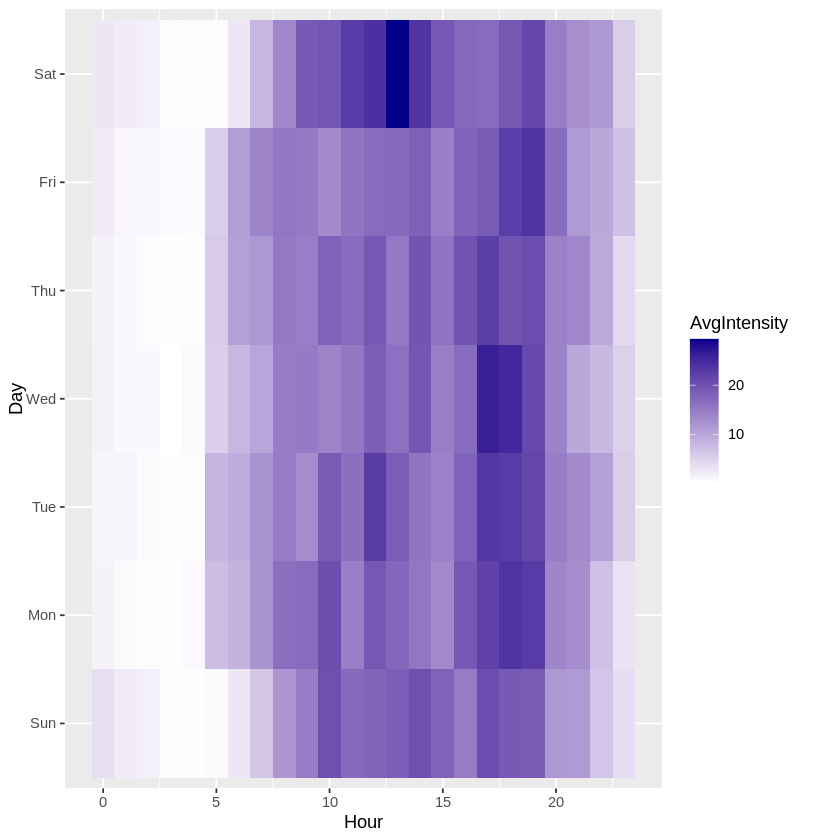

In [135]:
hourly_intensities %>%
    mutate(
        Hour = hour(ActivityHour),
        Day = wday(ActivityHour,
                   label = TRUE)
    ) %>%
    group_by(Day, Hour) %>%
    summarise(
        AvgIntensity = mean(TotalIntensity),
        .groups = "drop"
    ) %>%
    ggplot(aes(Hour,
               Day,
               fill = AvgIntensity)) +
    geom_tile() +
    scale_fill_gradient(low = "white", high = "darkblue")

In [140]:
# Define weekdays
daily_activity$Weekday <- weekdays(daily_activity$ActivityDate)
# Define weekend
daily_activity$Weekend <-
  ifelse(
    daily_activity$Weekday %in%
    c("Saturday", "Sunday"),
    "Weekend",
    "Weekday"
  )

In [141]:
print('Verifying new columns in daily_activity:')
glimpse(daily_activity)
head(daily_activity)

[1] "Verifying new columns in daily_activity:"
Rows: 940
Columns: 17
$ Id                       <dbl> 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityDate             <dttm> 2016-04-12, 2016-04-13, 2016-04-14, 2016-04-…
$ TotalSteps               <int> 13162, 10735, 10460, 9762, 12669, 9705, 13019…
$ TotalDistance            <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ TrackerDistance          <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ LoggedActivitiesDistance <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveDistance       <dbl> 1.88, 1.57, 2.44, 2.14, 2.71, 3.19, 3.25, 3.5…
$ ModeratelyActiveDistance <dbl> 0.55, 0.69, 0.40, 1.26, 0.41, 0.78, 0.64, 1.3…
$ LightActiveDistance      <dbl> 6.06, 4.71, 3.91, 2.83, 5.04, 2.51, 4.71, 5.0…
$ SedentaryActiveDistance  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveMinutes        <int> 25, 21, 30, 29, 36, 38, 42, 50, 28, 19, 66, 4…
$ FairlyActiveMinutes      <int> 13, 19, 11, 34, 10

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Weekday,Weekend
,<dbl>,<dttm>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,1503960366,2016-04-12,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,Tuesday,Weekday
2,1503960366,2016-04-13,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,Wednesday,Weekday
3,1503960366,2016-04-14,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776,Thursday,Weekday
4,1503960366,2016-04-15,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,Friday,Weekday
5,1503960366,2016-04-16,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,Saturday,Weekend
6,1503960366,2016-04-17,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728,Sunday,Weekend


In [ ]:
ggplot()

In [142]:
daily_activity_monthly <- daily_activity %>%
  mutate(Month = month(ActivityDate, label = TRUE, abbr = FALSE)) %>%
  group_by(Month) %>%
  summarise(
    AvgTotalSteps = mean(TotalSteps, na.rm = TRUE),
    AvgCalories = mean(Calories, na.rm = TRUE),
    .groups = 'drop'
  )

print("Monthly Average Activity:")
glimpse(daily_activity_monthly)
head(daily_activity_monthly)

[1] "Monthly Average Activity:"
Rows: 2
Columns: 3
$ Month         <ord> April, May
$ AvgTotalSteps <dbl> 7811.327, 7315.851
$ AvgCalories   <dbl> 2342.646, 2231.112


Month,AvgTotalSteps,AvgCalories
<ord>,<dbl>,<dbl>
April,7811.327,2342.646
May,7315.851,2231.112


In [182]:
daily_activity$TotalActiveMinutes <-
  daily_activity$VeryActiveMinutes +
    daily_activity$FairlyActiveMinutes +
    daily_activity$LightlyActiveMinutes


glimpse(daily_activity)
head(daily_activity)

Rows: 940
Columns: 18
$ Id                       <dbl> 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityDate             <dttm> 2016-04-12, 2016-04-13, 2016-04-14, 2016-04-…
$ TotalSteps               <int> 13162, 10735, 10460, 9762, 12669, 9705, 13019…
$ TotalDistance            <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ TrackerDistance          <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ LoggedActivitiesDistance <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveDistance       <dbl> 1.88, 1.57, 2.44, 2.14, 2.71, 3.19, 3.25, 3.5…
$ ModeratelyActiveDistance <dbl> 0.55, 0.69, 0.40, 1.26, 0.41, 0.78, 0.64, 1.3…
$ LightActiveDistance      <dbl> 6.06, 4.71, 3.91, 2.83, 5.04, 2.51, 4.71, 5.0…
$ SedentaryActiveDistance  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveMinutes        <int> 25, 21, 30, 29, 36, 38, 42, 50, 28, 19, 66, 4…
$ FairlyActiveMinutes      <int> 13, 19, 11, 34, 10, 20, 16, 31, 12, 8, 27, 21…
$ LightlyActiveMin

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Weekday,Weekend,TotalActiveMinutes
,<dbl>,<dttm>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>
1,1503960366,2016-04-12,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,Tuesday,Weekday,366
2,1503960366,2016-04-13,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,Wednesday,Weekday,257
3,1503960366,2016-04-14,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776,Thursday,Weekday,222
4,1503960366,2016-04-15,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,Friday,Weekday,272
5,1503960366,2016-04-16,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,Saturday,Weekend,267
6,1503960366,2016-04-17,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728,Sunday,Weekend,222


In [165]:
# Average steps, calories and active minutes per user, then categorize them by activity level
user_summary <-
  daily_activity %>%
    group_by(Id) %>%
    summarize(
      AverageSteps = mean(TotalSteps),
      AverageCalories = mean(Calories),
      AverageActive = mean(TotalActiveMinutes)
    ) %>%
  mutate(ActivityLevel = case_when(
    AverageSteps < 5000 ~ "Sedentary",
    AverageSteps < 7500 ~ "Lightly Active",
    AverageSteps < 10000 ~ "SomewhatActive",
    AverageSteps >= 10000 ~ "Active"
  ))
  # Count users
  count(user_summary, ActivityLevel)

ActivityLevel,n
<chr>,<int>
Active,7
Lightly Active,9
Sedentary,8
SomewhatActive,9


Hour,AverageSteps
<int>,<dbl>
0,42.188437
1,23.102894
2,17.110397
3,6.426581
4,12.699571
5,43.869099
6,178.508056
7,306.049409
8,427.544576


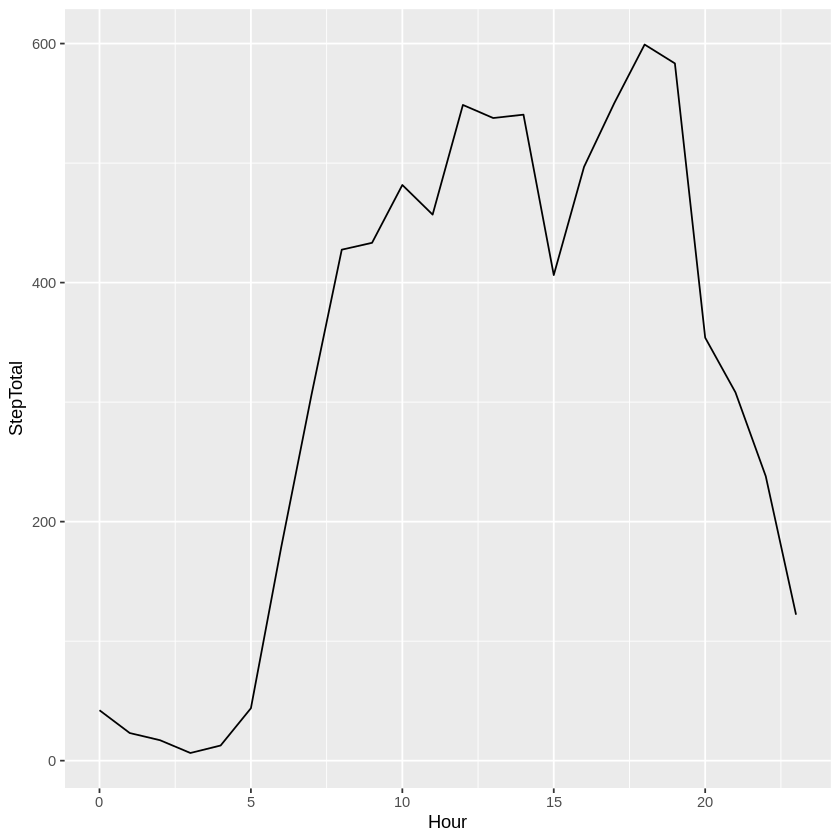

In [181]:
# Extract Hour
hourly_steps$Hour <- hour(hourly_steps$ActivityHour)
# Average hourly steps
hourly_steps %>%
  group_by(Hour) %>%
  summarize (AverageSteps = mean(StepTotal))
ggplot(hourly_steps, aes(x = Hour, y = StepTotal)) +
  stat_summary(fun = mean, geom = "line")